In [296]:
import numpy as np
import pandas as pd

In [297]:
data=pd.read_csv("/content/G2.csv")
data.head()

,id,name,height_dm,weight_hg,base_experience,type_1,type_2,hp,attack,defense
0,1,bulbasaur,7,69,64.0,grass,poison,45,49,49
1,2,ivysaur,10,130,142.0,grass,poison,60,62,63
2,3,venusaur,20,1000,236.0,grass,poison,80,82,83
3,4,charmander,6,85,62.0,fire,NaN,39,52,43
4,5,charmeleon,11,190,142.0,fire,NaN,58,64,58


In [298]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1351 entries, 0 to 1350
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1351 non-null   int64  
 1   name             1351 non-null   object 
 2   height_dm        1351 non-null   int64  
 3   weight_hg        1351 non-null   int64  
 4   base_experience  1302 non-null   float64
 5   type_1           1351 non-null   object 
 6   type_2           765 non-null    object 
 7   hp               1351 non-null   int64  
 8   attack           1351 non-null   int64  
 9   defense          1351 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 105.7+ KB


In [299]:
data['base_experience'] = pd.to_numeric(
    data['base_experience'],
    errors='coerce'
)

In [300]:
data.shape

(1351, 10)

In [301]:
data.describe()

,id,height_dm,weight_hg,base_experience,hp,attack,defense
count,1351.000000,1351.000000,1351.000000,1302.000000,1351.000000,1351.000000,1351.000000
mean,2841.692080,20.443375,991.059956,161.943932,71.673575,82.757957,76.193930
std,4139.019112,53.238467,1953.115812,82.532554,26.827529,32.351906,30.712902
min,1.000000,1.000000,0.000000,36.000000,1.000000,5.000000,5.000000
25%,338.500000,6.000000,94.500000,71.000000,55.000000,60.000000,55.000000
50%,676.000000,11.000000,326.000000,165.000000,70.000000,80.000000,70.000000
75%,1013.500000,17.000000,853.500000,222.500000,85.000000,102.500000,95.000000
max,10326.000000,1000.000000,10000.000000,608.000000,255.000000,190.000000,250.000000


In [302]:
data.isnull().sum()

,0
id,0
name,0
height_dm,0
weight_hg,0
base_experience,49
type_1,0
type_2,586
hp,0
attack,0
defense,0


In [303]:
data.duplicated().sum()

np.int64(0)

In [304]:
data["type_2"]=data["type_2"].fillna(data["type_2"].mode()[0])

In [305]:
data["base_experience"]=data["base_experience"].fillna(data["base_experience"].median())


In [306]:
data["type_1"].value_counts()

,count
type_1,
water,160
normal,139
grass,122
electric,100
bug,95
psychic,86
fire,84
rock,83
dark,63


In [307]:
import seaborn as sns
import matplotlib.pyplot as plt

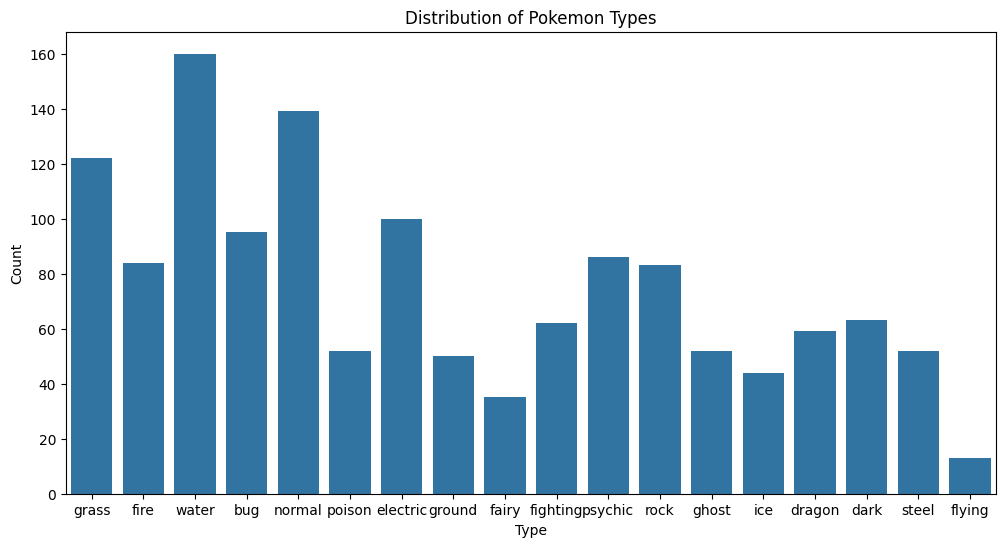

In [308]:
plt.figure(figsize=(12, 6))
sns.countplot(x="type_1", data=data)
plt.title("Distribution of Pokemon Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

Analytical Questions

1.type- "water" has appears most frequently in the dataset

2.numerical feature "weight_hg" shows the great variation 1953.12

3.what initial obesrvations can you make about the dataset

data shape : 1351 rows and 10 columns

"base_experience", "type 2" consisit of null values and there is no duplicate data

"type_1 is the target data in the dataset



In [309]:
num_cols = data.select_dtypes(include=np.number).columns.tolist()
cat_cols = data.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
['id', 'height_dm', 'weight_hg', 'base_experience', 'hp', 'attack', 'defense']

Categorical Columns:
['name', 'type_1', 'type_2']


In [310]:
num_features = [
    col for col in num_cols
    if col not in ['id']
]

print(num_features)

['height_dm', 'weight_hg', 'base_experience', 'hp', 'attack', 'defense']


In [311]:
cat_features = [
    col for col in cat_cols
    if col not in ['type_1']
]

print(cat_features)

['name', 'type_2']


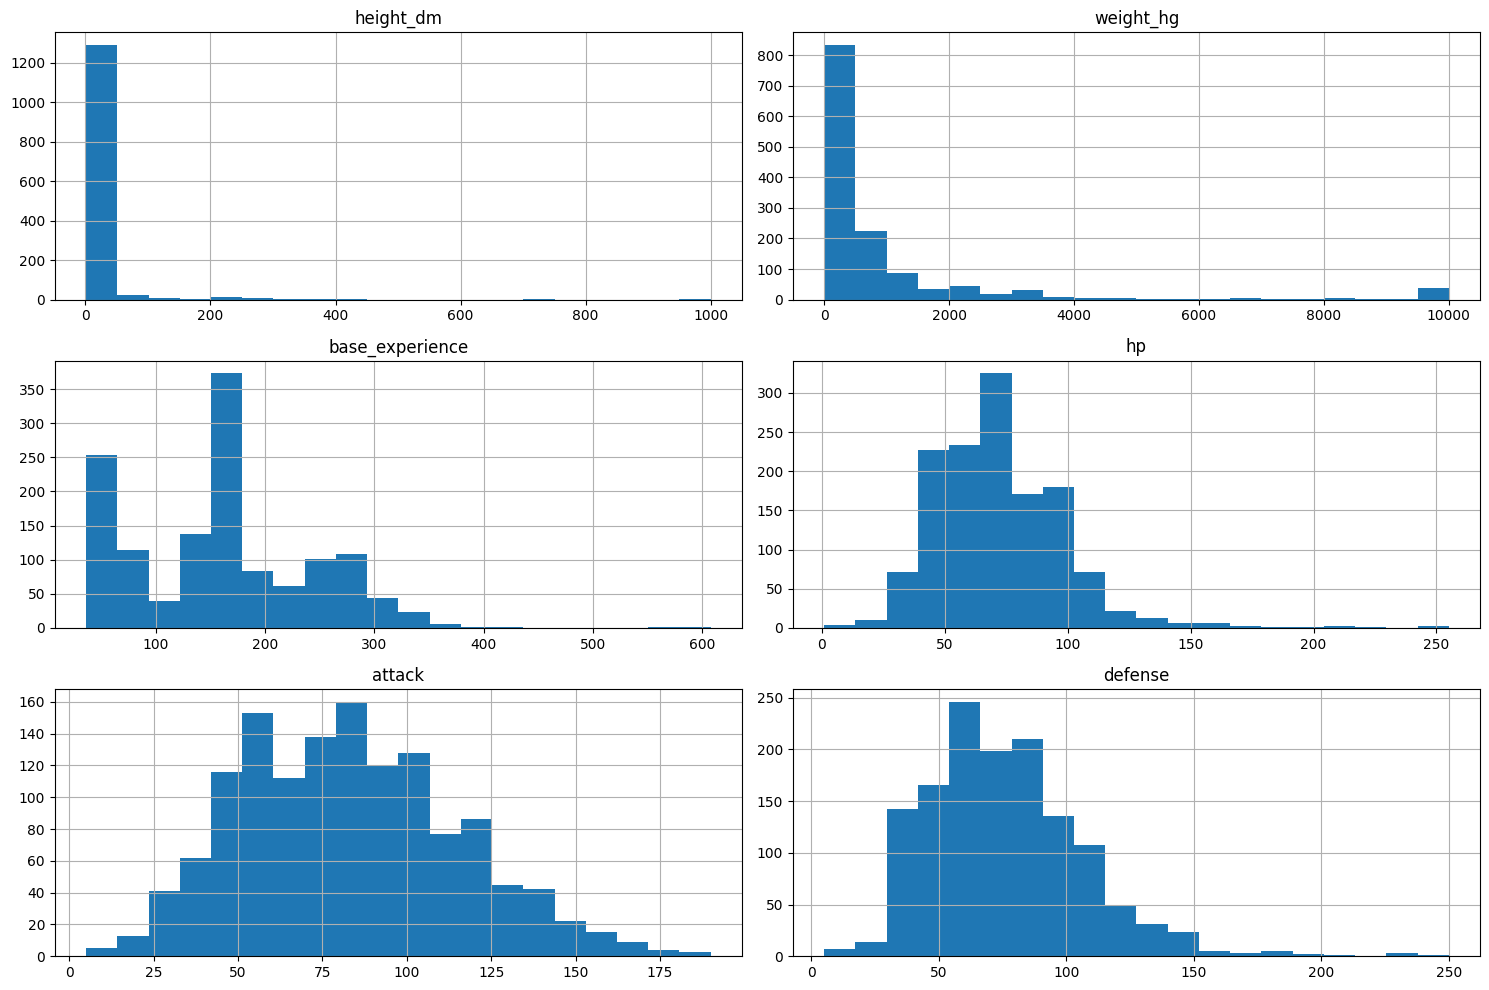

In [312]:
data[num_features].hist(
    figsize=(15, 10),
    bins=20
)

plt.tight_layout()
plt.show()

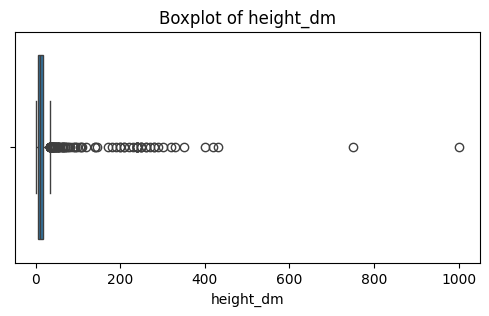

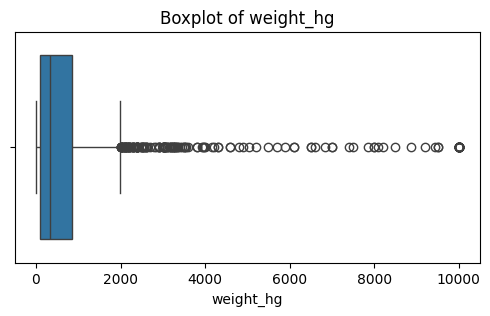

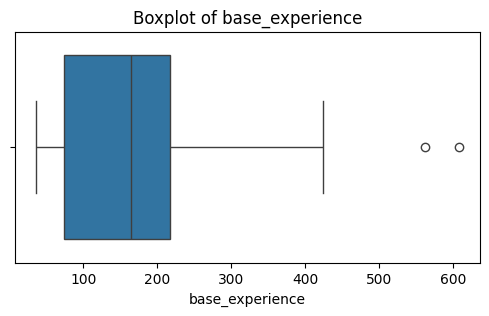

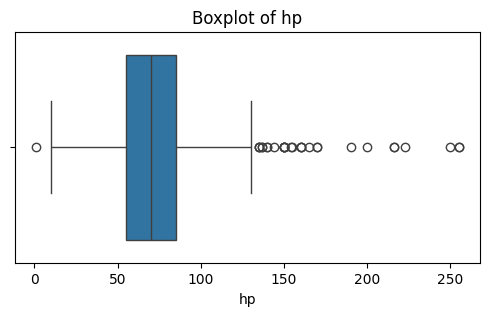

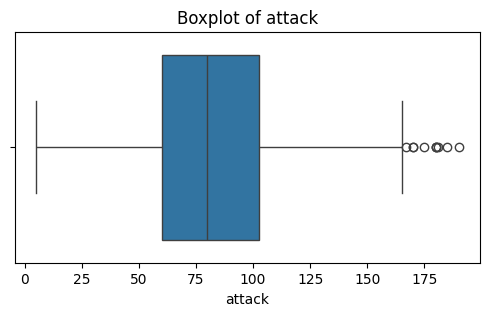

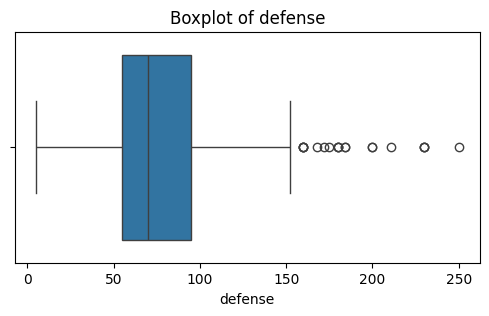

In [313]:
for col in num_features:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

1.why preprocessing essential before training



Preprocessing is essential because it cleans missing values and converts categorical data into numerical form so the machine-learning model can train correctly.

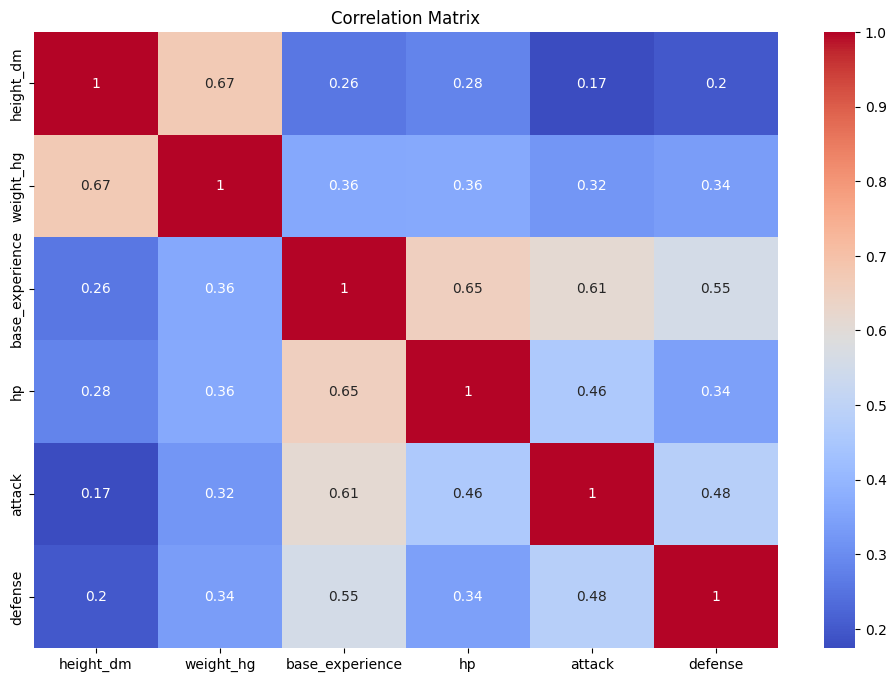

In [314]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    data[num_features].corr(),
    annot=True,
    cmap='coolwarm',

)

plt.title('Correlation Matrix')
plt.show()

In [315]:
data=data.drop(columns=["id", "name","type_2"])

In [317]:
data.head()

,height_dm,weight_hg,base_experience,type_1,hp,attack,defense
0,7,69,64.0,grass,45,49,49
1,10,130,142.0,grass,60,62,63
2,20,1000,236.0,grass,80,82,83
3,6,85,62.0,fire,39,52,43
4,11,190,142.0,fire,58,64,58


In [318]:
X = data.drop(columns=['type_1'])
y = data['type_1']

In [319]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1351, 6)
y shape: (1351,)


In [320]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [321]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test  :", y_test.shape)

X_train: (1080, 6)
X_test : (271, 6)
y_train: (1080,)
y_test  : (271,)


In [322]:
from sklearn.preprocessing import StandardScaler

col = ['height_dm', 'weight_hg', 'base_experience', 'hp', 'attack', 'defense']

scaler = StandardScaler()
X_train[col] = scaler.fit_transform(X_train[col])
X_test[col] = scaler.transform(X_test[col])

In [323]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

EDA

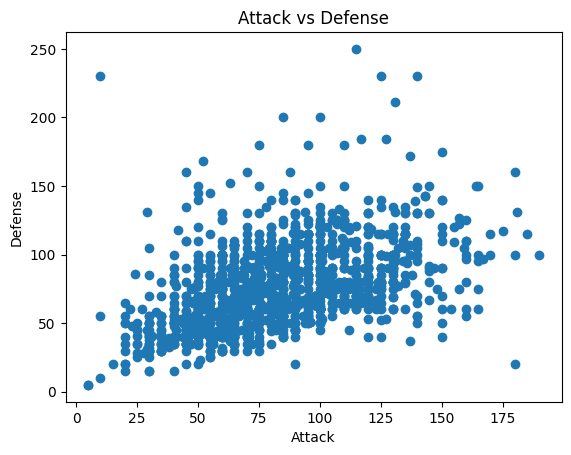

In [324]:
import matplotlib.pyplot as plt

plt.scatter(data["attack"], data["defense"])

plt.xlabel("Attack")
plt.ylabel("Defense")
plt.title("Attack vs Defense")

plt.show()

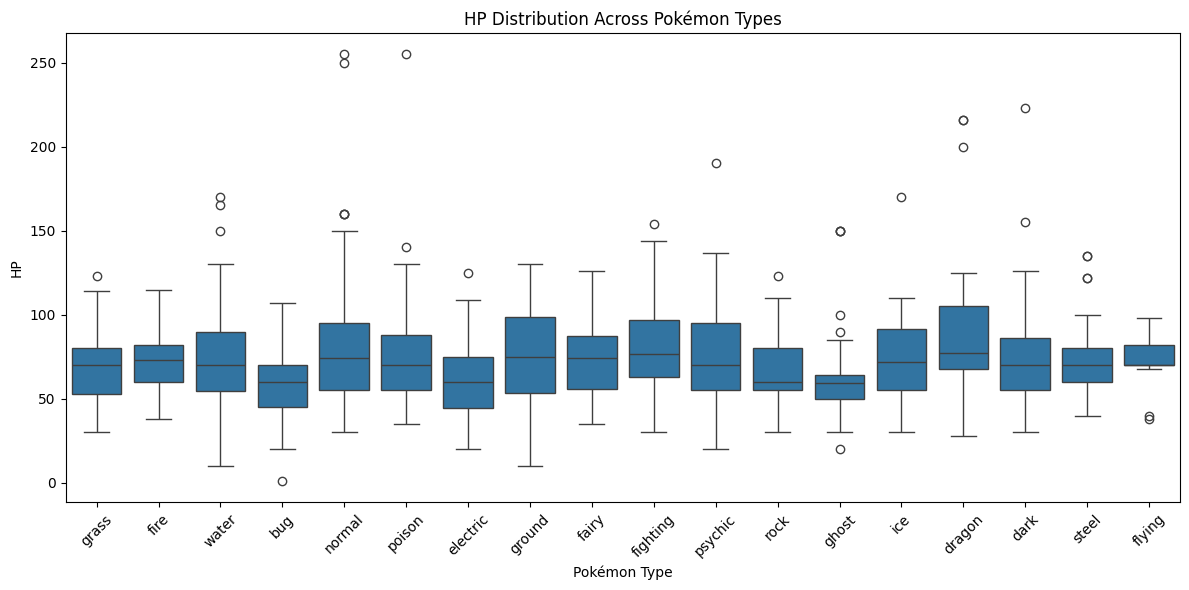

In [325]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x="type_1", y="hp")

plt.title("HP Distribution Across Pokémon Types")
plt.xlabel("Pokémon Type")
plt.ylabel("HP")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

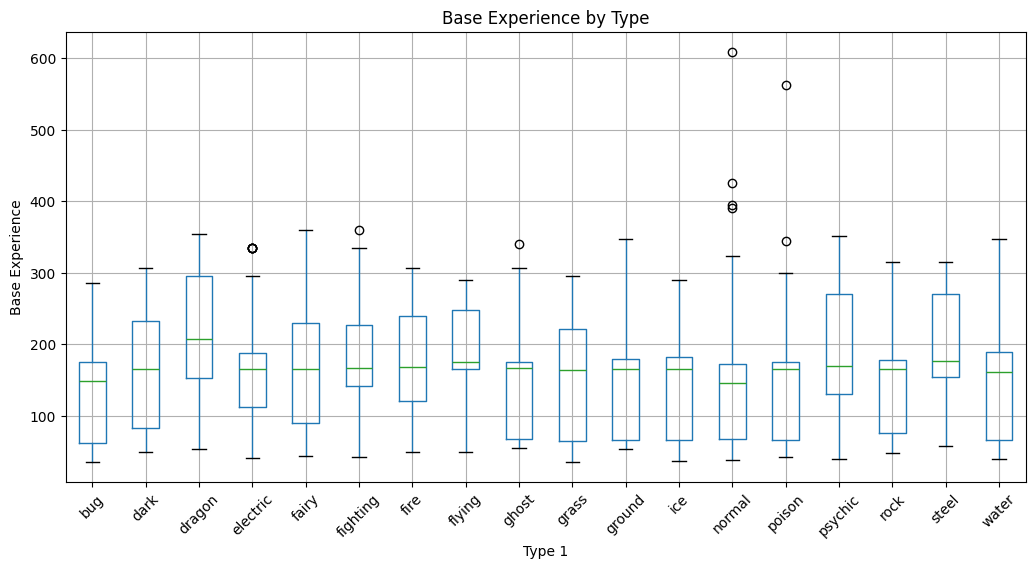

In [326]:
data.boxplot(
    column="base_experience",
    by="type_1",
    figsize=(12, 6)
)

plt.title("Base Experience by Type")
plt.suptitle("")
plt.xlabel("Type 1")
plt.ylabel("Base Experience")
plt.xticks(rotation=45)
plt.show()

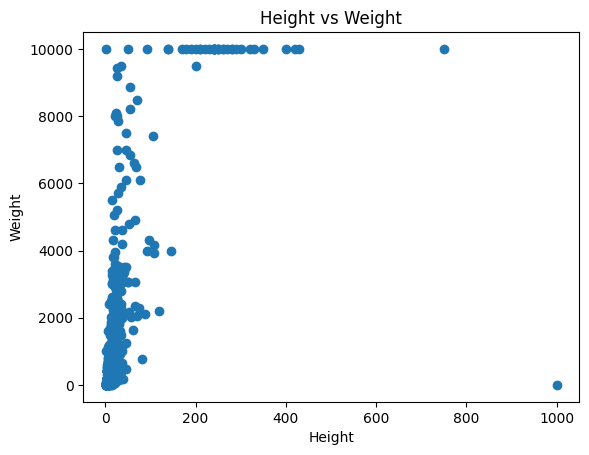

In [327]:
plt.scatter(data["height_dm"], data["weight_hg"])
plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Height vs Weight")
plt.show()

which pokeman type tends highest average attack

fighting'

is there a relation between height and weight

no

:
which feature appear most usefull for distinguishing pokemon

Model Training

In [328]:
X.isna().sum()

,0
height_dm,0
weight_hg,0
base_experience,0
hp,0
attack,0
defense,0


In [332]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


y_pred_rf = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_rf,
        average="macro",
        zero_division=0
    )
)

print(
    "Recall   :",
    recall_score(
        y_test,
        y_pred_rf,
        average="macro",
        zero_division=0
    )
)

print(
    "F1 Score :",
    f1_score(
        y_test,
        y_pred_rf,
        average="macro",
        zero_division=0
    )
)

Accuracy : 0.2693726937269373
Precision: 0.23752894527404333
Recall   : 0.22244154881925782
F1 Score : 0.22262285226274134


In [343]:
from sklearn.linear_model import LogisticRegression
model_log = LogisticRegression()
model_log.fit(X_train,y_train)
y_pred = model_log.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("accuracy:", accuracy_score(y_test,y_pred))
print("classification report:",classification_report(y_test,y_pred))
plt.show()

accuracy: 0.16974169741697417
classification report:               precision    recall  f1-score   support

           0       0.14      0.16      0.15        19
           1       0.00      0.00      0.00        13
           2       0.20      0.17      0.18        12
           3       0.14      0.30      0.19        20
           4       0.00      0.00      0.00         7
           5       0.08      0.08      0.08        12
           6       0.00      0.00      0.00        17
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00        10
           9       0.22      0.08      0.12        25
          10       0.00      0.00      0.00        10
          11       0.00      0.00      0.00         9
          12       0.22      0.39      0.29        28
          13       0.00      0.00      0.00        10
          14       0.00      0.00      0.00        17
          15       0.23      0.29      0.26        17
          16       0.44     

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [336]:
import pickle
pickle.dump(scaler,open('standard.pkl','wb'))
pickle.dump(model_rf,open('model.pkl','wb'))

In [338]:
from google.colab import files

files.download('model.pkl')
files.download('standard.pkl')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

random forest performs best

